In [7]:
!pip install tensorflow tensorflow-datasets matplotlib numpy opencv-python pillow -q

  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler

# Загрузка датасета
(train_ds, test_ds), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
IMG_SIZE = (100, 100)
BATCH_SIZE = 64

# Аугментация данных
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Функции предобработки
def preprocess_train(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    image = data_augmentation(image)
    return image, label

def preprocess_test(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

# Подготовка данных
train_ds = train_ds.map(preprocess_train).shuffle(1000).batch(BATCH_SIZE)
test_ds = test_ds.map(preprocess_test).batch(BATCH_SIZE)

# Разделение на train/validation
train_size = int(0.8 * len(list(train_ds.unbatch())))
train_dataset_full = train_ds.take(train_size)
val_dataset = train_ds.skip(train_size)

# Модель с улучшенной регуляризацией
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        32, (3, 3), 
        activation='relu', 
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(100, 100, 3)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.Conv2D(
        64, (3, 3), 
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(3, activation='softmax')
])

# Learning rate scheduler
def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

# Компиляция
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=0.00001,
        verbose=1
    ),
    LearningRateScheduler(lr_schedule)
]

# Обучение
EPOCHS = 2
history = model.fit(
    train_dataset_full,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Финальная оценка на тестовых данных
print("\nОценка на тестовых данных:")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Точность: {test_acc*100:.2f}%")
print(f"Потери: {test_loss:.4f}")

# Проверка на переобучение
if 'accuracy' in history.history and 'val_accuracy' in history.history:
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"\nTrain accuracy: {train_acc*100:.2f}%")
    print(f"Val accuracy: {val_acc*100:.2f}%")
    if train_acc - val_acc > 0.15:
        print("⚠️ Предупреждение: Большая разница между train и val accuracy!")
else:
    print("\nИнформация об accuracy недоступна в истории")

# Сохранение модели
model.save('rps_model_improved.keras')
print("\n✅ Модель сохранена как 'rps_model_regularized.keras'")

# Дополнительная информация
print(f"\nКоличество эпох обучения: {len(history.history.get('loss', []))}")
print(f"Лучшая точность на валидации: {max(history.history.get('val_accuracy', [0]))*100:.2f}%")

Epoch 1/2


C:\study\AIMMO\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 562ms/step - accuracy: 0.3964 - loss: 1.2757 - learning_rate: 5.0000e-04
Epoch 2/2


C:\study\AIMMO\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
C:\study\AIMMO\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
C:\study\AIMMO\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 529ms/step - accuracy: 0.5131 - loss: 1.0343 - learning_rate: 5.0000e-04

Оценка на тестовых данных:
Точность: 33.33%
Потери: 1.1758

Информация об accuracy недоступна в истории

✅ Модель сохранена как 'rps_model_regularized.keras'

Количество эпох обучения: 2
Лучшая точность на валидации: 0.00%


In [12]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# 1. Загрузка модели
print("Загружаю модель...")
model = tf.keras.models.load_model('rps_model_regularized.keras')
IMG_SIZE = (150, 150)
class_names = ['rock', 'paper', 'scissors']

# 2. Запрос файла
image_path = input("Введите имя файла с фото руки: ").strip()

# 3. Проверка
if not os.path.exists(image_path):
    print("Файл не найден!")
    exit()

# 4. Обработка
img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 5. Предсказание
predictions = model.predict(img_array, verbose=0)[0]
predicted_idx = np.argmax(predictions)

# 6. Результат
print(f"\nРезультат: {class_names[predicted_idx]}")
print(f"Уверенность: {predictions[predicted_idx]*100:.1f}%")

Загружаю модель...


Введите имя файла с фото руки:  3.jpg



Результат: rock
Уверенность: 100.0%


In [13]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("TensorFlow version:", tf.__version__)



# Загрузка датасета Rock-Paper-Scissors
(train_ds, test_ds), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# Получаем названия классов
class_names = ds_info.features['label'].names
print("Классы:", class_names)
print("Тренировочных изображений:", ds_info.splits['train'].num_examples)
print("Тестовых изображений:", ds_info.splits['test'].num_examples)


# Параметры
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Функция для подготовки изображений
def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0  # Нормализация
    return image, label

# Применяем предобработку
train_ds = train_ds.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE)
test_ds = test_ds.map(preprocess_image).batch(BATCH_SIZE)



# Простая модель
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 класса
])

# Компиляция
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



# Обучение модели
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

# Сохранение модели
model.save('rps_model.h5')
print("Модель сохранена как 'rps_model.h5'")

TensorFlow version: 2.20.0
Классы: ['rock', 'paper', 'scissors']
Тренировочных изображений: 2520
Тестовых изображений: 372


C:\study\AIMMO\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 338ms/step - accuracy: 0.7361 - loss: 0.7553 - val_accuracy: 0.8952 - val_loss: 0.3996
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 325ms/step - accuracy: 0.9952 - loss: 0.0252 - val_accuracy: 0.8844 - val_loss: 0.4882
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 325ms/step - accuracy: 0.9972 - loss: 0.0114 - val_accuracy: 0.7581 - val_loss: 1.2078
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 327ms/step - accuracy: 0.9996 - loss: 0.0041 - val_accuracy: 0.8683 - val_loss: 0.6724
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 330ms/step - accuracy: 1.0000 - loss: 1.8477e-04 - val_accuracy: 0.8710 - val_loss: 0.6764


Модель сохранена как 'rps_model.h5'



ТЕСТИРОВАНИЕ НА ВАШЕЙ ФОТОГРАФИИ
1. Сфотографируйте жест (камень, ножницы или бумага)
2. Сохраните фото в папке с этим кодом
3. Введите имя файла ниже



Введите имя вашего файла (например: my_hand.jpg):  2.jpg



РЕЗУЛЬТАТЫ РАСПОЗНАВАНИЯ:
Файл: 2.jpg
Жест: rock
Уверенность: 58.5%

Все вероятности:
-> rock:  58.5%
   paper:  30.3%
   scissors:  11.2%


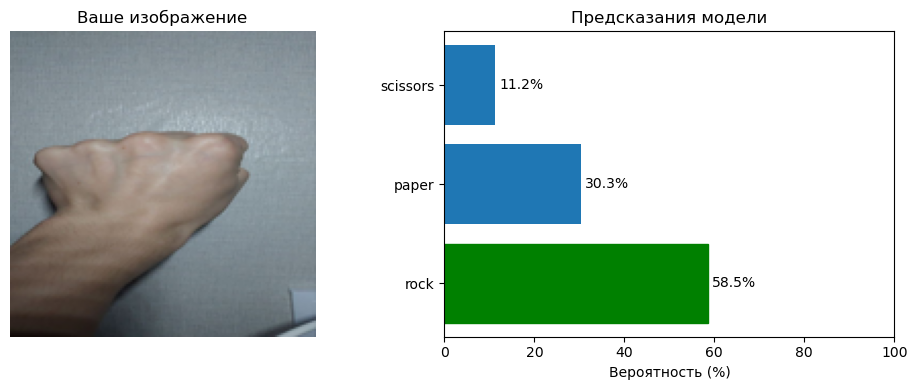


ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ
Точность модели: 87.10%
Потери модели: 0.6764


In [15]:
def test_my_image(image_path):
    """
    Тестирует модель на вашем изображении
    
    Args:
        image_path: путь к вашему изображению
    """
    
    # Проверка файла
    if not os.path.exists(image_path):
        print(f"Ошибка: файл '{image_path}' не найден!")
        return
    
    # Загрузка и предобработка
    img = Image.open(image_path).convert('RGB')
    img = img.resize(IMG_SIZE)
    
    # Конвертация в numpy array
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Добавляем batch dimension
    
    # Предсказание
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class = np.argmax(predictions)
    confidence = predictions[predicted_class] * 100
    
    # Вывод результатов
    print("\n" + "="*40)
    print("РЕЗУЛЬТАТЫ РАСПОЗНАВАНИЯ:")
    print("="*40)
    print(f"Файл: {os.path.basename(image_path)}")
    print(f"Жест: {class_names[predicted_class]}")
    print(f"Уверенность: {confidence:.1f}%")
    print("\nВсе вероятности:")
    
    for i, (cls, prob) in enumerate(zip(class_names, predictions)):
        marker = "->" if i == predicted_class else "  "
        print(f"{marker} {cls}: {prob*100:5.1f}%")
    
    # Визуализация
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Ваше изображение")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    bars = plt.barh(class_names, predictions * 100)
    bars[predicted_class].set_color('green')
    plt.xlabel('Вероятность (%)')
    plt.title('Предсказания модели')
    plt.xlim([0, 100])
    
    # Добавляем значения на столбцы
    for bar, prob in zip(bars, predictions * 100):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{prob:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()

# Тестируем модель на вашем изображении
print("\n" + "="*40)
print("ТЕСТИРОВАНИЕ НА ВАШЕЙ ФОТОГРАФИИ")
print("="*40)
print("1. Сфотографируйте жест (камень, ножницы или бумага)")
print("2. Сохраните фото в папке с этим кодом")
print("3. Введите имя файла ниже")

# Запрос пути к файлу
image_path = input("\nВведите имя вашего файла (например: my_hand.jpg): ").strip()

# Если файл не указан, создаем демо-изображение
if not image_path:
    print("\nСоздаю демо-изображение...")
    
    # Создаем простое изображение "камня"
    img = np.ones((300, 300, 3), dtype=np.uint8) * 200
    # Рисуем круг (камень)
    import cv2
    cv2.circle(img, (150, 150), 100, (100, 100, 100), -1)
    
    # Сохраняем
    image_path = 'demo_rock.jpg'
    from PIL import Image
    Image.fromarray(img).save(image_path)
    print(f"Создано демо-изображение: {image_path}")

# Тестируем
test_my_image(image_path)

# Оценка точности модели на тестовых данных
print("\n" + "="*40)
print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*40)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Точность модели: {test_accuracy*100:.2f}%")
print(f"Потери модели: {test_loss:.4f}")